

##  Decoding the OpenAI CLIP Model

This project dives deep into the inner workings of **OpenAI’s CLIP (Contrastive Language–Image Pre-training)** model — focusing specifically on how **image and text representations are encoded, projected, and aligned** within a shared multimodal embedding space.

Through this implementation, we reconstruct and analyze the **core architecture of CLIP**, including:

* The **VisionTransformer (ViT)** module for image feature extraction.
* The **Transformer-based text encoder** for processing tokenized text.
* The **projection layers** that map both modalities into a unified embedding space.

Our objective is to **decode and understand** how CLIP connects vision and language by learning powerful cross-modal representations, enabling it to match images and text with remarkable accuracy.

This project serves as both an **educational exploration** and a **clean reimplementation** of the essential CLIP mechanisms — from embedding generation and normalization to the final cosine similarity computation that drives its zero-shot performance.

---

### Key Concepts Covered

* VisionTransformer-based visual feature encoding
* Transformer-based text embedding and positional encoding
* Layer normalization and multimodal projection
* Cosine similarity and contrastive loss dynamics

---



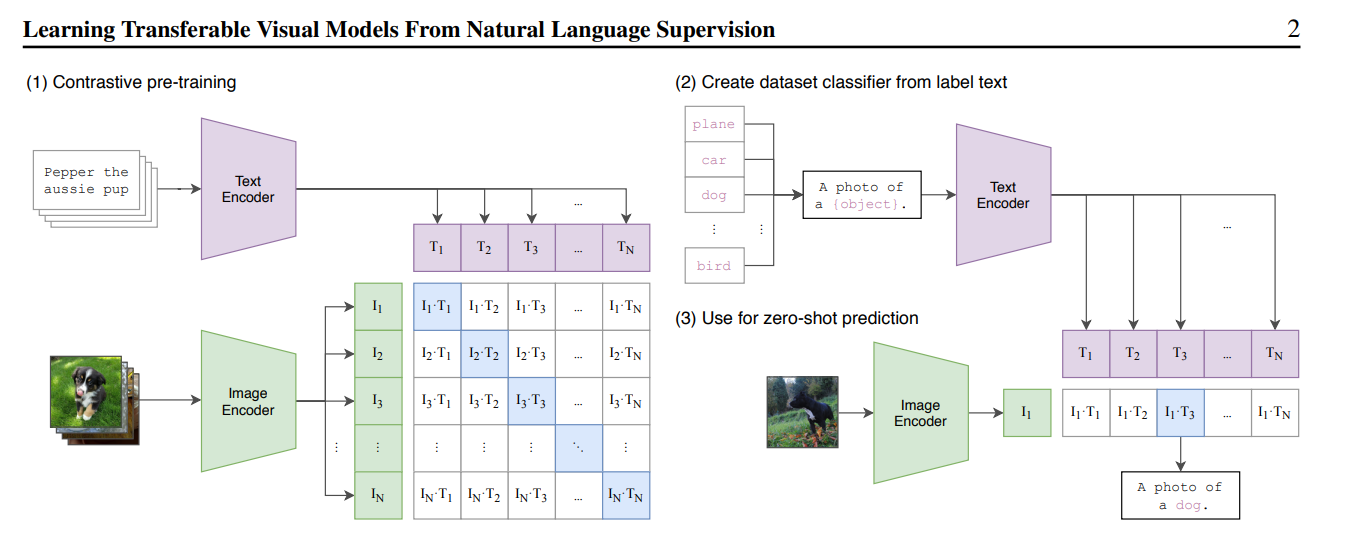

In [2]:
import torch
import torch
import torch.nn as nn
from torch.nn import LayerNorm
from collections import OrderedDict

In [3]:
class QuickGELU(nn.Module):
    def forward(self, x: torch.Tensor):
        return x * torch.sigmoid(1.702 * x)

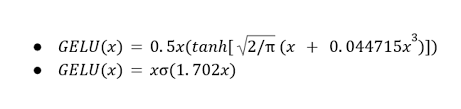

In [4]:
class ResidualAttentionBlock(nn.Module):
    def __init__(self, d_model: int, n_head: int, attn_mask: torch.Tensor = None):
        super().__init__()

        self.attn = nn.MultiheadAttention(d_model, n_head)
        self.ln_1 = LayerNorm(d_model)
        self.mlp = nn.Sequential(OrderedDict([
            ("c_fc", nn.Linear(d_model, d_model * 4)),
            ("gelu", QuickGELU()),
            ("c_proj", nn.Linear(d_model * 4, d_model))
        ]))
        self.ln_2 = LayerNorm(d_model)
        self.attn_mask = attn_mask

    def attention(self, x: torch.Tensor):
        self.attn_mask = self.attn_mask.to(dtype=x.dtype, device=x.device) if self.attn_mask is not None else None
        return self.attn(x, x, x, need_weights=False, attn_mask=self.attn_mask)[0]

    def forward(self, x: torch.Tensor):
        x = x + self.attention(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

In [ ]:
class Transformer(nn.Module):
    def __init__(self, width: int, layers: int, heads: int, attn_mask: torch.Tensor = None):
        super().__init__()
        self.width = width
        self.layers = layers
        self.resblocks = nn.Sequential(*[ResidualAttentionBlock(width, heads, attn_mask) for _ in range(layers)])

    def forward(self, x: torch.Tensor):
        return self.resblocks(x)

Transformer model used same as decoder only model for example -"GPT2"

[Already implemented from scratch github link()]

In [5]:
class LayerNorm(nn.LayerNorm):
 

    def forward(self, x: torch.Tensor): 
        orig_type = x.dtype
        ret = super().forward(x.type(torch.float32))
        return ret.type(orig_type)

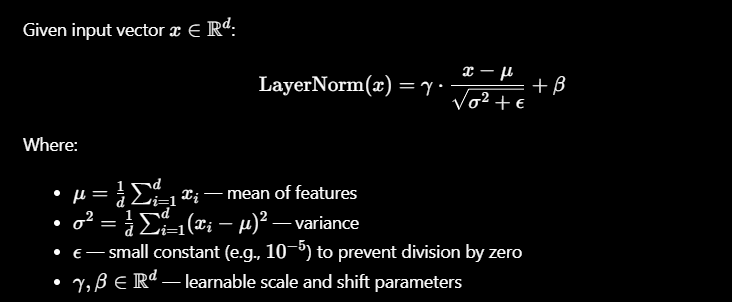

In [6]:
class VisionTransformer(nn.Module):
    def __init__(self, input_resolution: int, patch_size: int, width: int, layers: int, heads: int, output_dim: int):
        super().__init__()
        self.input_resolution = input_resolution
        self.output_dim = output_dim
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=width, kernel_size=patch_size, stride=patch_size, bias=False)

        scale = width ** -0.5
        self.class_embedding = nn.Parameter(scale * torch.randn(width))
        self.positional_embedding = nn.Parameter(scale * torch.randn((input_resolution // patch_size) ** 2 + 1, width))
        self.ln_pre = LayerNorm(width)

        self.transformer = Transformer(width, layers, heads)

        self.ln_post = LayerNorm(width)
        self.proj = nn.Parameter(scale * torch.randn(width, output_dim))

Vit  model used same "ViT-B/16"
[Already implemented from scratch github link()]

In [ ]:

import numpy as np


class CLIP(nn.Module):
    def __init__(self,
                 embed_dim: int,
                 image_resolution: int,
                 vision_layers: int,
                 vision_width: int,
                 vision_patch_size: int,
                 context_length: int,
                 vocab_size: int,
                 embedding_dim: int,
                 transformer_heads: int,
                 transformer_layers: int):
        super().__init__()

        self.context_length = context_length
        self.vocab_size = vocab_size

        # ---- Vision Encoder (ViT) ----
        vision_heads = vision_width // 64
        self.visual = VisionTransformer(
            input_resolution=image_resolution,
            patch_size=vision_patch_size,
            width=vision_width,
            layers=vision_layers,
            heads=vision_heads,
            output_dim=embed_dim
        )

       
        self.transformer = Transformer(
            width=embedding_dim,
            layers=transformer_layers,
            heads=transformer_heads,
            attn_mask=self.build_attention_mask()
        )

        self.token_embedding = nn.Embedding(vocab_size, embedding_dim)
        self.positional_embedding = nn.Parameter(torch.empty(context_length, embedding_dim))
        self.ln_final = LayerNorm(embedding_dim)

        self.text_projection = nn.Parameter(torch.empty(embedding_dim, embed_dim))
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

        self.initialize_parameters()

    # ---- Initialization ----
    def initialize_parameters(self):
        # Here weight intialisation is done using normal distribution
        nn.init.normal_(self.token_embedding.weight, std=0.02)
        nn.init.normal_(self.positional_embedding, std=0.01)
        nn.init.normal_(self.text_projection, std=self.transformer.width ** -0.5)

        proj_std = (self.transformer.width ** -0.5) * ((2 * self.transformer.layers) ** -0.5)
        attn_std = self.transformer.width ** -0.5
        fc_std = (2 * self.transformer.width) ** -0.5

        for block in self.transformer.resblocks:
            nn.init.normal_(block.attn.in_proj_weight, std=attn_std)
            nn.init.normal_(block.attn.out_proj.weight, std=proj_std)
            nn.init.normal_(block.mlp.c_fc.weight, std=fc_std)
            nn.init.normal_(block.mlp.c_proj.weight, std=proj_std)

   
    # this will be used for text transformer to make it causal
    def build_attention_mask(self):
        mask = torch.empty(self.context_length, self.context_length)
        # This is creation of attention mask
        mask.fill_(float("-inf"))
        mask.triu_(1)
        return mask

    @property
    def dtype(self):
        return self.visual.conv1.weight.dtype

    # ---- Encode Image ----
    def encode_image(self, image):
        return self.visual(image.type(self.dtype))

    # ---- Encode Text ----
    def encode_text(self, text):
        x = self.token_embedding(text).type(self.dtype)
        x = x + self.positional_embedding.type(self.dtype)
        x = x.permute(1, 0, 2)  # NLD -> LND
        x = self.transformer(x)
        x = x.permute(1, 0, 2)  # LND -> NLD
        x = self.ln_final(x).type(self.dtype)
        x = x[torch.arange(x.shape[0]), text.argmax(dim=-1)] @ self.text_projection
        # In the image this is the text multimodal embedding conversion step done using W_t
        return x

    # ---- Forward ----
    def forward(self, image, text):
        image_features = self.encode_image(image)
        text_features = self.encode_text(text)

        image_features = image_features / image_features.norm(dim=1, keepdim=True)
        text_features = text_features / text_features.norm(dim=1, keepdim=True)

        logit_scale = self.logit_scale.exp()
        logits_per_image = logit_scale * image_features @ text_features.t()
        #This step is done in image through np.exp(t)
        logits_per_text = logits_per_image.t()

        return logits_per_image, logits_per_text


The Image shows our aim to increase the similarity score at the diagonal elements  as it denotes the  similarity score between corresponding text and image.

This is implemented through  the forward function in the Clip model class.

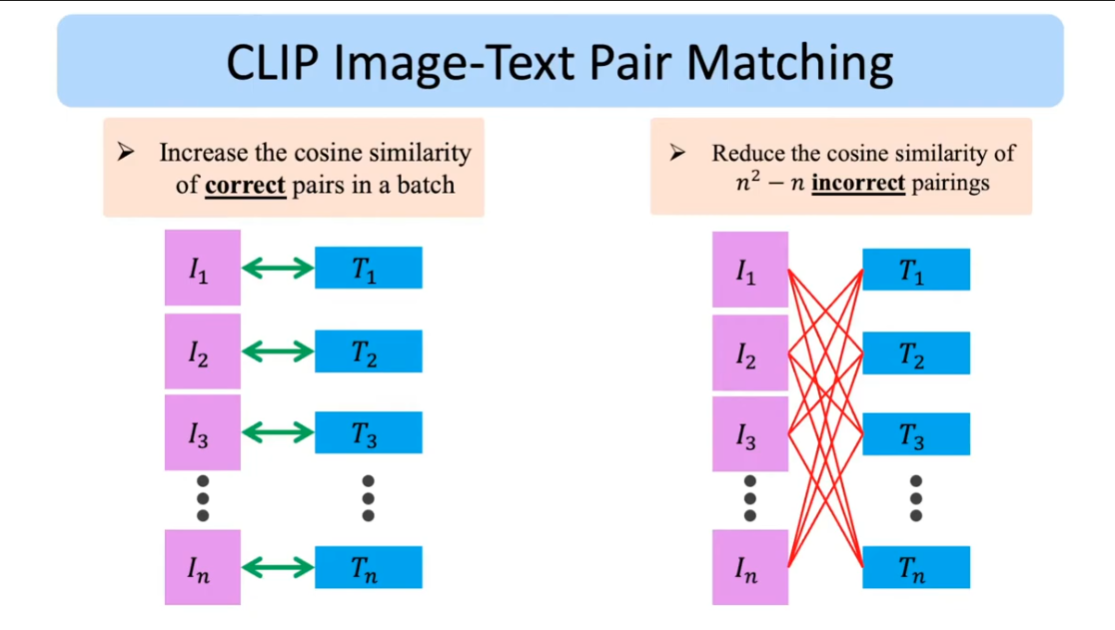

ABOUT LOSS FUNCTION

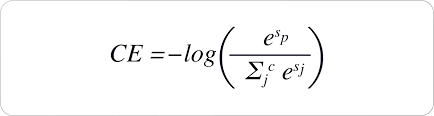

In [ ]:
import torch
import torch.nn.functional as F

def clip_loss(logits_per_image, logits_per_text):
    """
    Symmetric cross-entropy loss used in OpenAI CLIP.
    
    Args:
        logits_per_image: Tensor [N, N]
            Each entry (i, j) is the cosine similarity between image_i and text_j.
        logits_per_text: Tensor [N, N]
            Transpose of logits_per_image, i.e., (i, j) = similarity between text_i and image_j.
    
    Returns:
        Scalar symmetric loss (float)
    """

    N = logits_per_image.shape[0]
    ground_truth = torch.arange(N, dtype=torch.long, device=logits_per_image.device)

    # Axis meaning (referring to the paper diagram):
    # logits_per_image[i, j] = similarity between image i and text j
    #   axis=1 → over texts  (T1, T2, ..., TN) for each image i
    #   axis=0 → over images (I1, I2, ..., IN) for each text j
   

    # Cross entropy for image→text (rows)
    # Each image tries to correctly classify its matching text among all texts
    loss_i2t = F.cross_entropy(logits_per_image, ground_truth)  # axis=1

    # Cross entropy for text→image (columns)
    # Each text tries to correctly classify its matching image among all images
    loss_t2i = F.cross_entropy(logits_per_text, ground_truth)   # axis=0

    # Final symmetric loss = average of both directions
    loss = (loss_i2t + loss_t2i) / 2
    return loss


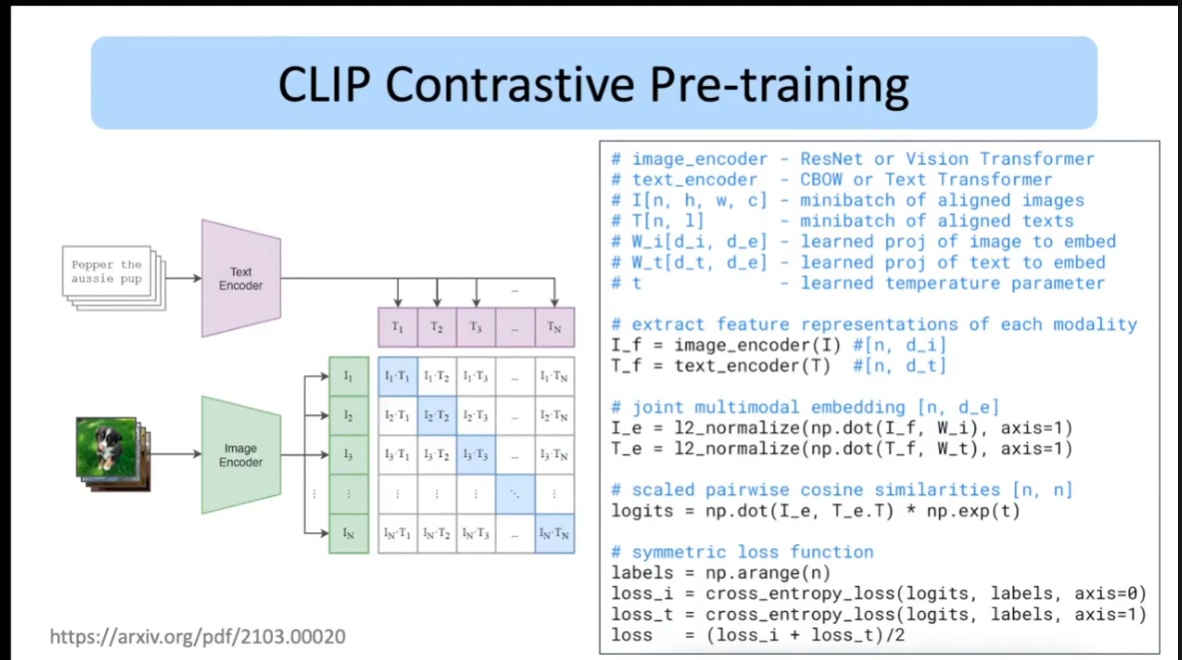

END



### 📌 First `permute(1, 0, 2)` — from **(N, L, D)** to **(L, N, D)**
- **Before permute**: `x` has shape `(N, L, D)`
  - `N`: batch size
  - `L`: sequence length
  - `D`: embedding dimension
- **Why permute?** The `transformer` module (likely a `nn.Transformer` or similar) expects input in the shape `(L, N, D)` — sequence-first format.
- So this rearrangement makes the tensor compatible with the transformer.

### 🔄 Second `permute(1, 0, 2)` — from **(L, N, D)** back to **(N, L, D)**
- After the transformer processes the data, you restore the original format so that subsequent layers (like `ln_final`) and indexing operations work as expected.

### 🧠 Summary
```python
x = x.permute(1, 0, 2)  # Prepare for transformer: (N, L, D) → (L, N, D)
x = self.transformer(x)
x = x.permute(1, 0, 2)  # Restore original shape: (L, N, D) → (N, L, D)
```